# Visualización estática — La Paz Traffic

Mapas Folium coloreados por cluster espacial y temporal + gráficos de perfiles horarios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from pathlib import Path
from shapely import wkt

DATA_RAW       = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
TIPOS_DIA      = ['lunes', 'viernes', 'sabado']

clustered = pd.read_csv(DATA_PROCESSED / 'segments_clustered.csv')
segs_info = pd.read_csv(DATA_RAW / 'sample_segments.csv')
feat_raw  = pd.read_csv(DATA_PROCESSED / 'feature_matrix.csv', index_col='segment_id')
edges_raw = pd.read_csv(DATA_RAW / 'lapaz_edges.csv')

# Deduplicar edges — puede haber múltiples aristas paralelas para el mismo (u,v)
edges_dedup = edges_raw.drop_duplicates(['u', 'v'])

df = clustered.merge(segs_info[['segment_id', 'u', 'v']], on='segment_id', how='left')
df = df.merge(edges_dedup[['u', 'v', 'geometry', 'name']], on=['u', 'v'], how='left')
df_valid = df[df['geometry'].notna()].copy().reset_index(drop=True)

def geom_to_latlon(wkt_str):
    return [[lat, lon] for lon, lat in wkt.loads(wkt_str).coords]

print(f'Segmentos con geometría: {len(df_valid)}/{len(df)}')
print(f'Clusters espaciales: {sorted(df_valid["cluster_espacial"].unique())}')
print(f'Clusters temporales: {sorted(df_valid["cluster_temporal"].unique())}')

Segmentos con geometría: 229/250
Clusters espaciales: [np.int64(-1), np.int64(0), np.int64(1)]
Clusters temporales: [np.int64(0), np.int64(1)]


## Mapa 1 — Clusters espaciales (DBSCAN)

In [2]:
COLORES_ESP = {-1: '#888888', 0: '#2196F3', 1: '#FF9800', 2: '#4CAF50'}

m1 = folium.Map(location=[-16.505, -68.130], zoom_start=13, tiles='CartoDB positron')
for _, row in df_valid.iterrows():
    c = int(row['cluster_espacial'])
    label = 'Outlier' if c == -1 else f'Cluster {c}'
    tip = (f"<b>{row['name'] if pd.notna(row['name']) else 'Sin nombre'}</b><br>"
           f"Cluster espacial: {label}<br>jam_factor: {row['jam_mean']:.3f}<br>Vía: {row['highway']}")
    folium.PolyLine(geom_to_latlon(row['geometry']),
                    color=COLORES_ESP.get(c,'#AAAAAA'), weight=3, opacity=0.8,
                    tooltip=folium.Tooltip(tip)).add_to(m1)

leyenda = '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;padding:12px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,.3);font-family:Arial"><b>Clusters espaciales</b><br><span style="color:#2196F3">&#9644;</span> Cluster 0<br><span style="color:#FF9800">&#9644;</span> Cluster 1<br><span style="color:#888">&#9644;</span> Outlier</div>'
m1.get_root().html.add_child(folium.Element(leyenda))
m1.save(str(DATA_PROCESSED / 'map_spatial_clusters.html'))
print('Guardado: map_spatial_clusters.html')
m1

Guardado: map_spatial_clusters.html


## Mapa 2 — Clusters temporales (K-Means)

In [3]:
# Determinar qué cluster tiene mayor congestión promedio
seg_cl = df_valid[['segment_id','cluster_temporal']].drop_duplicates('segment_id')
jam_por_cl = feat_raw.merge(seg_cl, left_index=True, right_on='segment_id', how='inner')
jam_medio = jam_por_cl.groupby('cluster_temporal').mean(numeric_only=True).mean(axis=1)
cluster_alto = int(jam_medio.idxmax())
print(f'Cluster de alta congestión: {cluster_alto}')

COLORES_TMP = {c: ('#E53935' if int(c)==cluster_alto else '#43A047')
               for c in df_valid['cluster_temporal'].unique()}

m2 = folium.Map(location=[-16.505, -68.130], zoom_start=13, tiles='CartoDB positron')
for _, row in df_valid.iterrows():
    c = int(row['cluster_temporal'])
    nivel = 'Alta congestión' if c == cluster_alto else 'Baja congestión'
    tip = (f"<b>{row['name'] if pd.notna(row['name']) else 'Sin nombre'}</b><br>"
           f"Cluster {c}: {nivel}<br>jam_factor: {row['jam_mean']:.3f}<br>Vía: {row['highway']}")
    folium.PolyLine(geom_to_latlon(row['geometry']),
                    color=COLORES_TMP[c], weight=3, opacity=0.8,
                    tooltip=folium.Tooltip(tip)).add_to(m2)

leyenda2 = f'<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;padding:12px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,.3);font-family:Arial"><b>Clusters temporales</b><br><span style="color:#E53935">&#9644;</span> Cluster {cluster_alto} — Alta congestión<br><span style="color:#43A047">&#9644;</span> Otros — Baja congestión</div>'
m2.get_root().html.add_child(folium.Element(leyenda2))
m2.save(str(DATA_PROCESSED / 'map_temporal_clusters.html'))
print('Guardado: map_temporal_clusters.html')
m2

Cluster de alta congestión: 0
Guardado: map_temporal_clusters.html


## Perfiles temporales por cluster

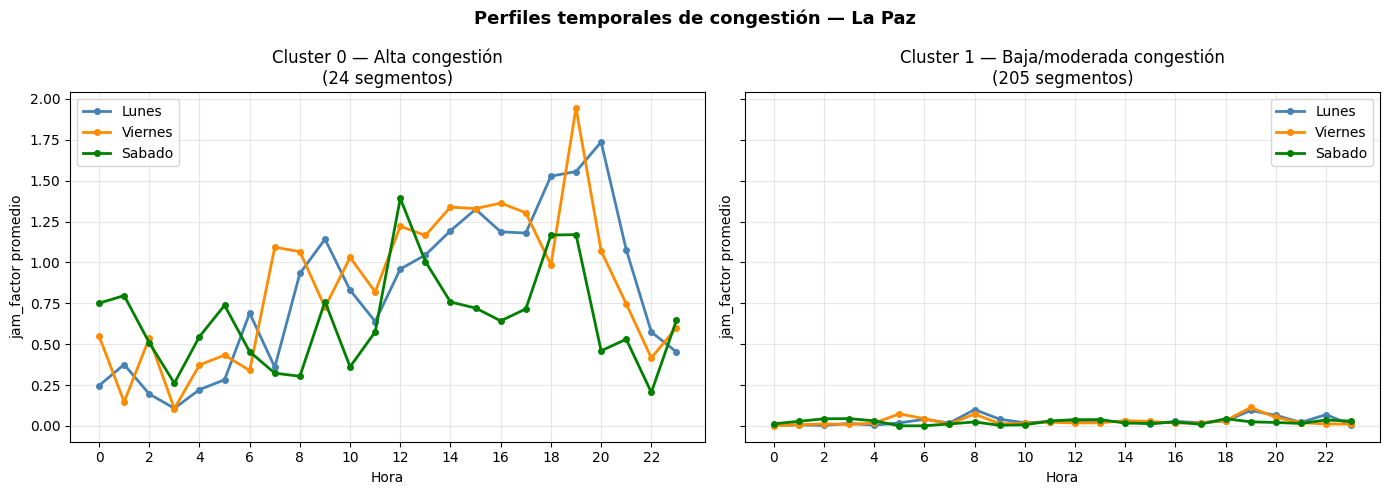

Guardado: temporal_profiles.png


In [4]:
clusters = sorted(df_valid['cluster_temporal'].unique())
fig, axes = plt.subplots(1, len(clusters), figsize=(7*len(clusters), 5), sharey=True)
if len(clusters) == 1: axes = [axes]
colores_dia = {'lunes': 'steelblue', 'viernes': 'darkorange', 'sabado': 'green'}

for ax, c in zip(axes, clusters):
    seg_ids = seg_cl[seg_cl['cluster_temporal']==c]['segment_id']
    mask = feat_raw.index.isin(seg_ids)
    for dia in TIPOS_DIA:
        cols = [f'jam_{dia}_{h:02d}' for h in range(24)]
        perfil = feat_raw.loc[mask, cols].mean().values
        ax.plot(range(24), perfil, 'o-', ms=4, lw=2,
                label=dia.capitalize(), color=colores_dia[dia])
    nivel = 'Alta congestión' if int(c)==cluster_alto else 'Baja/moderada congestión'
    ax.set_title(f'Cluster {c} — {nivel}\n({mask.sum()} segmentos)')
    ax.set_xlabel('Hora'); ax.set_ylabel('jam_factor promedio')
    ax.set_xticks(range(0,24,2)); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Perfiles temporales de congestión — La Paz', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'temporal_profiles.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: temporal_profiles.png')

## Resumen

Abrí los archivos HTML en el navegador para verificar los mapas.

Próximo paso: **FASE 9 — Dashboard Streamlit**.